# Sesión 2: Análisis Topológico de la Serie FRED (WPUSI01102B)

## Producer Price Index: Berries

**Objetivo:** Aplicar técnicas de Topología de Datos (embedding de Takens, homología persistente) para detectar estacionalidad y cambios abruptos en el índice de precios al productor de bayas (fresas, frambuesas, zarzamoras, arándanos).

**Fuente de datos:** FRED, Federal Reserve Bank of St. Louis
**Serie:** WPUSI01102B
**Periodo:** junio 2008 – abril 2026 (datos mensuales)
**Unidades:** Índice (base 1982 = 100)

---
**Autor:** Dr. Hugo García Tecocoatzi  


In [1]:
# ============================================================
# Librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Para análisis topológico
from gtda.time_series import SingleTakensEmbedding, TakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude
from gtda.plotting import plot_diagram
from ripser import ripser
from persim import plot_diagrams

# Para reducción dimensional
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ============================================================
# CARGAR DATOS DESDE CSV
# ============================================================

# Cargar el archivo CSV (asegúrate de que esté en el mismo directorio o agrega el path)
df = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])

# Ver las primeras filas
print("Vista previa de los datos:")
print(df.head(10))

# Información del dataset
print("\n" + "="*50)
print(" INFORMACIÓN DEL DATASET:")
print("="*50)
print(f"Total de registros: {len(df)}")
print(f"Periodo: {df['observation_date'].min()} a {df['observation_date'].max()}")
print(f"Frecuencia: mensual")
print(f"Valores faltantes: {df['WPUSI01102B'].isna().sum()}")

# Ver estadísticas básicas
print("\n ESTADÍSTICAS BÁSICAS:")
print(df['WPUSI01102B'].describe())

Vista previa de los datos:
  observation_date  WPUSI01102B
0       2008-06-01        100.0
1       2008-07-01         81.4
2       2008-08-01        110.6
3       2008-09-01        111.8
4       2008-10-01        125.2
5       2008-11-01        145.2
6       2008-12-01        216.7
7       2009-01-01        205.3
8       2009-02-01        186.3
9       2009-03-01        189.5

 INFORMACIÓN DEL DATASET:
Total de registros: 215
Periodo: 2008-06-01 00:00:00 a 2026-04-01 00:00:00
Frecuencia: mensual
Valores faltantes: 0

 ESTADÍSTICAS BÁSICAS:
count    215.000000
mean     142.467456
std       44.815860
min       69.200000
25%      109.087500
50%      130.200000
75%      171.600000
max      299.382000
Name: WPUSI01102B, dtype: float64


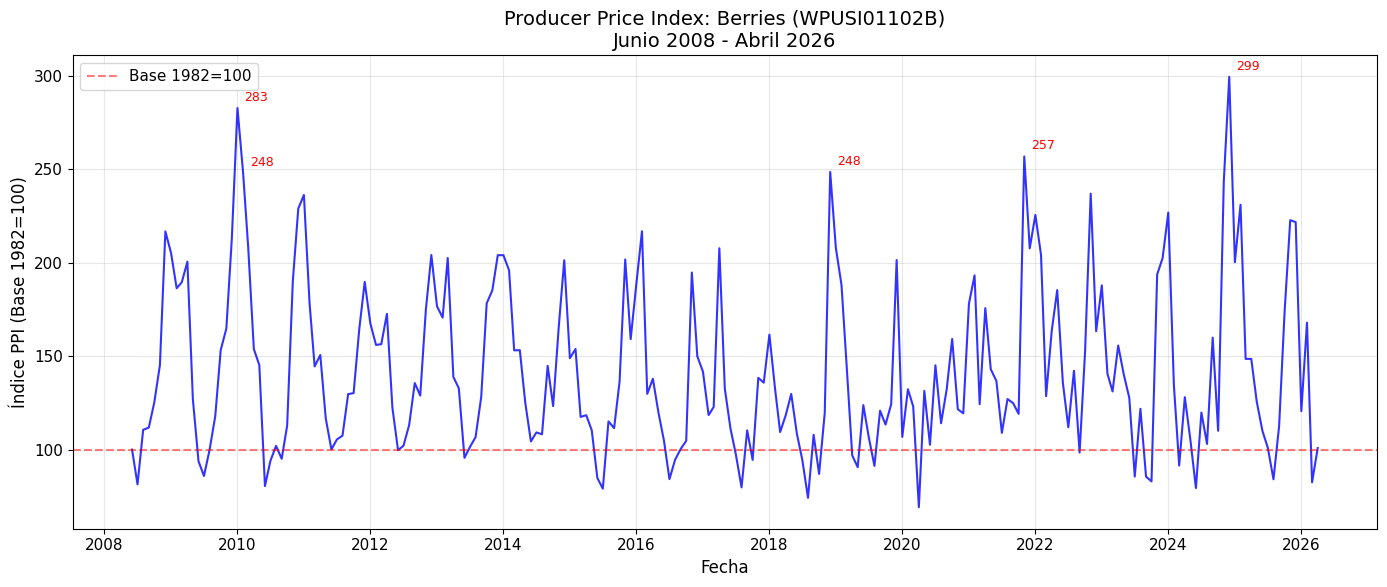


 OBSERVACIONES:
   - Fuerte estacionalidad anual (picos a finales de año)
   - Picos extremos: finales de 2024 (299.4) y 2010 (282.7)
   - Valles profundos: primavera/verano


In [3]:
# ============================================================
# VISUALIZAR LA SERIE COMPLETA
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['observation_date'], df['WPUSI01102B'], 'b-', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Índice PPI (Base 1982=100)', fontsize=12)
ax.set_title('Producer Price Index: Berries (WPUSI01102B)\nJunio 2008 - Abril 2026', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Base 1982=100')

# Marcar algunos picos notables
picos = [(df['observation_date'].iloc[i], df['WPUSI01102B'].iloc[i]) 
         for i in df['WPUSI01102B'].nlargest(5).index]
for fecha, valor in picos:
    ax.annotate(f'{valor:.0f}', xy=(fecha, valor), xytext=(5, 5), 
                textcoords='offset points', fontsize=9, color='red')

ax.legend()
plt.tight_layout()
plt.show()

print("\n OBSERVACIONES:")
print("   - Fuerte estacionalidad anual (picos a finales de año)")
print("   - Picos extremos: finales de 2024 (299.4) y 2010 (282.7)")
print("   - Valles profundos: primavera/verano")

## Actividad 1: Análisis por Subperiodos

Vamos a dividir la serie en tres subperiodos para comparar su topología:

1. **2008-2012:** Crisis financiera, precios volátiles
2. **2013-2019:** Relativa estabilidad pre-pandemia
3. **2020-2026:** Pandemia y post-pandemia (alta inflación)

Para cada subperiodo, aplicaremos embedding de Takens y calcularemos diagramas de persistencia.

📊 SUBPERIODOS DEFINIDOS:
   2008-2012: 55 meses
   2013-2019: 84 meses
   2020-2026: 76 meses


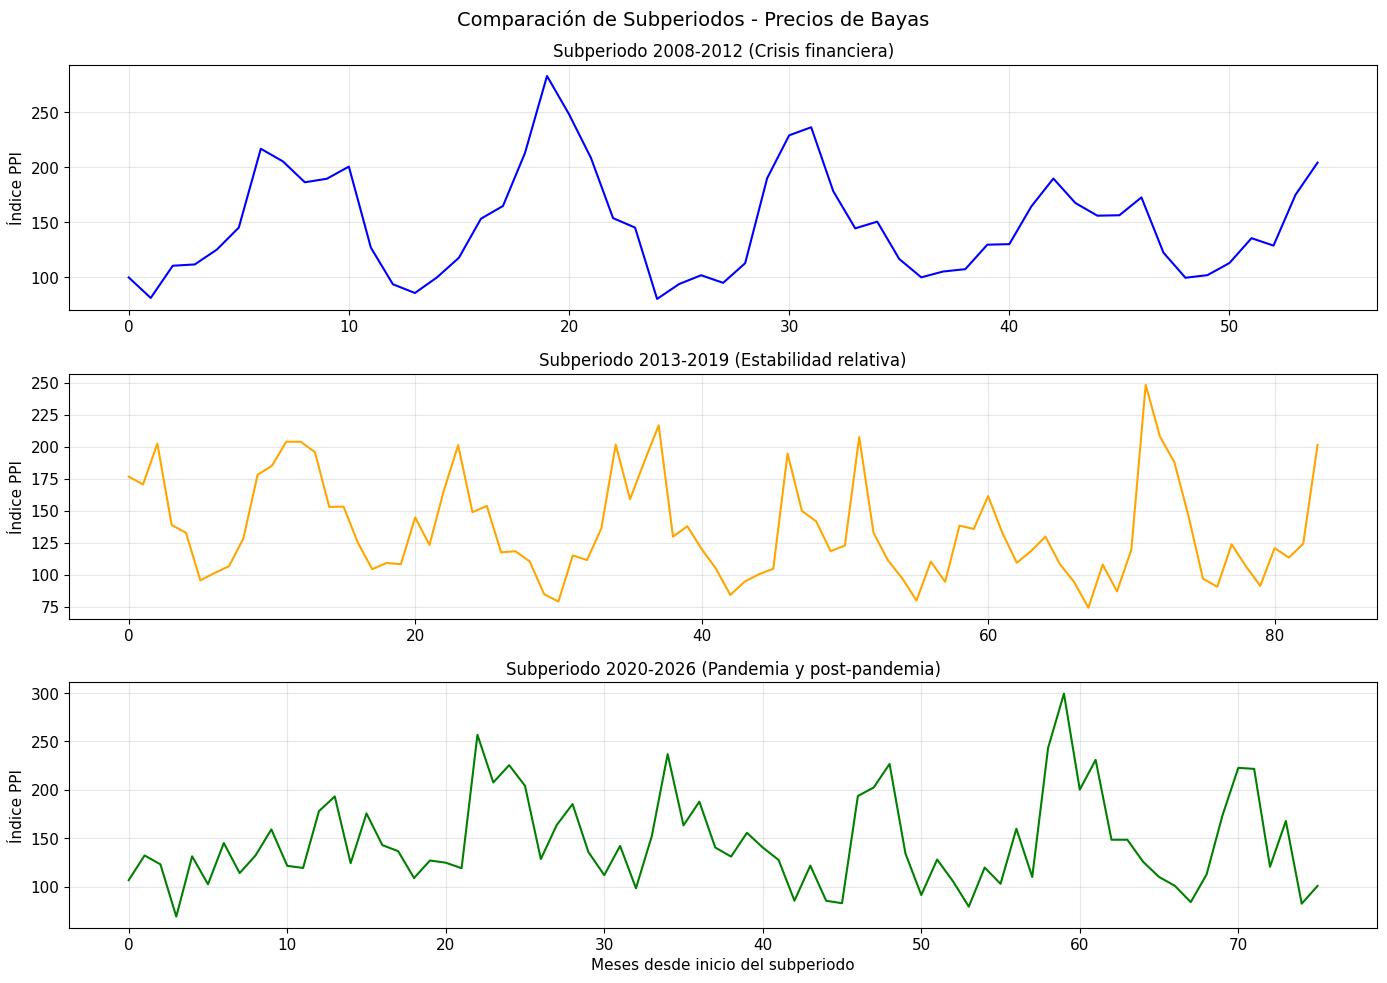

In [4]:
# ============================================================
# DEFINIR SUBPERIODOS
# ============================================================

# Convertir a array numpy para facilitar el manejo
fechas = df['observation_date'].values
precios = df['WPUSI01102B'].values.astype(float)

# Definir máscaras para cada subperiodo
mask_2008_2012 = (fechas >= np.datetime64('2008-06-01')) & (fechas <= np.datetime64('2012-12-31'))
mask_2013_2019 = (fechas >= np.datetime64('2013-01-01')) & (fechas <= np.datetime64('2019-12-31'))
mask_2020_2026 = (fechas >= np.datetime64('2020-01-01')) & (fechas <= np.datetime64('2026-04-30'))

# Extraer datos
precios_2008_2012 = precios[mask_2008_2012]
precios_2013_2019 = precios[mask_2013_2019]
precios_2020_2026 = precios[mask_2020_2026]

print("📊 SUBPERIODOS DEFINIDOS:")
print(f"   2008-2012: {len(precios_2008_2012)} meses")
print(f"   2013-2019: {len(precios_2013_2019)} meses")
print(f"   2020-2026: {len(precios_2020_2026)} meses")

# Visualizar los subperiodos
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(precios_2008_2012, 'b-', linewidth=1.5)
axes[0].set_title('Subperiodo 2008-2012 (Crisis financiera)', fontsize=12)
axes[0].set_ylabel('Índice PPI')
axes[0].grid(True, alpha=0.3)

axes[1].plot(precios_2013_2019, 'orange', linewidth=1.5)
axes[1].set_title('Subperiodo 2013-2019 (Estabilidad relativa)', fontsize=12)
axes[1].set_ylabel('Índice PPI')
axes[1].grid(True, alpha=0.3)

axes[2].plot(precios_2020_2026, 'green', linewidth=1.5)
axes[2].set_title('Subperiodo 2020-2026 (Pandemia y post-pandemia)', fontsize=12)
axes[2].set_xlabel('Meses desde inicio del subperiodo')
axes[2].set_ylabel('Índice PPI')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparación de Subperiodos - Precios de Bayas', fontsize=14)
plt.tight_layout()
plt.show()

## Actividad 2: Embedding de Takens

**Parámetros elegidos (inspirados en estacionalidad):**
- **dimensión (d) = 12** → un año completo de datos mensuales
- **τ (time_delay) = 3** → captura patrones trimestrales
- **stride = 1** → máximo aprovechamiento de datos

**¿Qué esperamos?** Una señal estacional pura mostraría un **círculo** en el espacio de embedding (β₁ = 1). Ruido puro mostraría una **bola** (β₁ = 0).

Calculando embeddings...
Embedding 2008-2012: (22, 12)
Embedding 2013-2019: (51, 12)
Embedding 2020-2026: (43, 12)


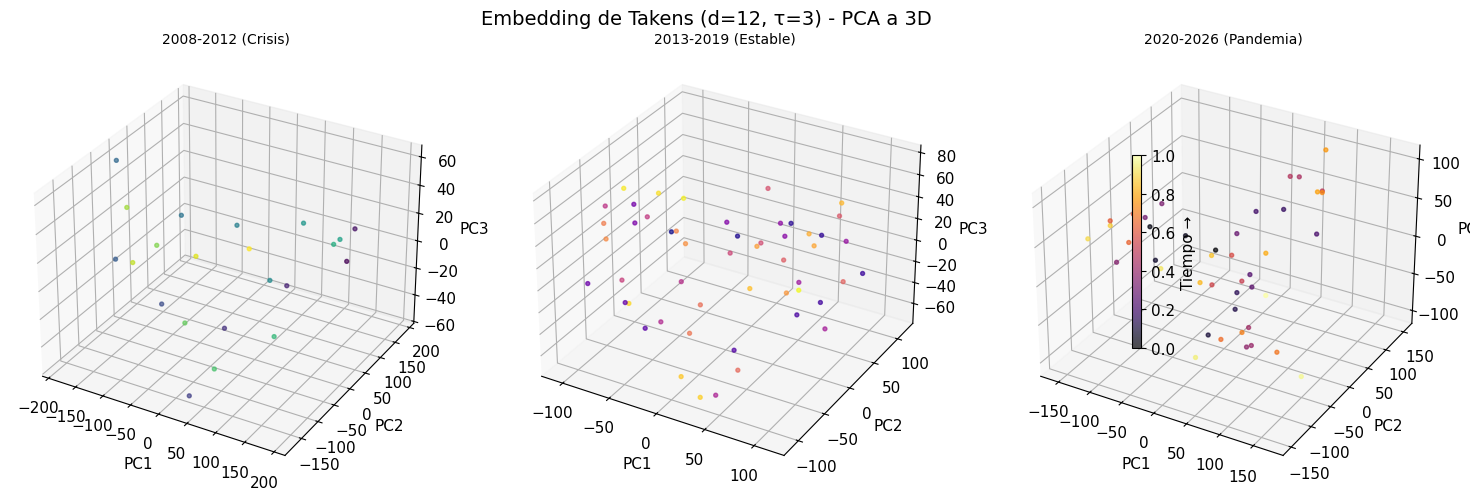

In [5]:
# ============================================================
# EMBEDDING DE TAKENS PARA CADA SUBPERIODO
# ============================================================

from gtda.time_series import SingleTakensEmbedding

# Parámetros
dimension = 12
time_delay = 3

STE = SingleTakensEmbedding(
    parameters_type="fixed",
    dimension=dimension,
    time_delay=time_delay
)

# Calcular embeddings
print("Calculando embeddings...")
embedding_2008 = STE.fit_transform(precios_2008_2012)
embedding_2013 = STE.fit_transform(precios_2013_2019)
embedding_2020 = STE.fit_transform(precios_2020_2026)

print(f"Embedding 2008-2012: {embedding_2008.shape}")
print(f"Embedding 2013-2019: {embedding_2013.shape}")
print(f"Embedding 2020-2026: {embedding_2020.shape}")

# PCA a 3D para visualización
pca = PCA(n_components=3)

embed_2008_pca = pca.fit_transform(embedding_2008)
embed_2013_pca = pca.fit_transform(embedding_2013)
embed_2020_pca = pca.fit_transform(embedding_2020)

# Visualización 3D
fig = plt.figure(figsize=(15, 5))

# Subperiodo 2008-2012
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(embed_2008_pca[:, 0], embed_2008_pca[:, 1], embed_2008_pca[:, 2],
                  c=np.linspace(0, 1, len(embed_2008_pca)), cmap='viridis', s=8, alpha=0.7)
ax1.set_title('2008-2012 (Crisis)', fontsize=10)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# Subperiodo 2013-2019
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(embed_2013_pca[:, 0], embed_2013_pca[:, 1], embed_2013_pca[:, 2],
                  c=np.linspace(0, 1, len(embed_2013_pca)), cmap='plasma', s=8, alpha=0.7)
ax2.set_title('2013-2019 (Estable)', fontsize=10)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Subperiodo 2020-2026
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(embed_2020_pca[:, 0], embed_2020_pca[:, 1], embed_2020_pca[:, 2],
                  c=np.linspace(0, 1, len(embed_2020_pca)), cmap='inferno', s=8, alpha=0.7)
ax3.set_title('2020-2026 (Pandemia)', fontsize=10)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')

plt.suptitle('Embedding de Takens (d=12, τ=3) - PCA a 3D', fontsize=14)
plt.colorbar(sc3, ax=[ax1, ax2, ax3], label='Tiempo →', shrink=0.5)
plt.tight_layout()
plt.show()

📊 CONFIGURACIÓN DEL EMBEDDING
   Dimensión (d): 12
   Retardo (τ): 3
   Stride: 1

⏳ Calculando embeddings...
Embedding 2008-2012: (22, 12)
Embedding 2013-2019: (51, 12)
Embedding 2020-2026: (43, 12)
   2008-2012 (sin norm): varianza PC1=0.43, PC2=0.43, PC3=0.03
   2013-2019 (sin norm): varianza PC1=0.30, PC2=0.30, PC3=0.06
   2020-2026 (sin norm): varianza PC1=0.25, PC2=0.25, PC3=0.13
   2008-2012 (normalizada): varianza PC1=0.43, PC2=0.43, PC3=0.03
   2013-2019 (normalizada): varianza PC1=0.30, PC2=0.30, PC3=0.06
   2020-2026 (normalizada): varianza PC1=0.25, PC2=0.25, PC3=0.13


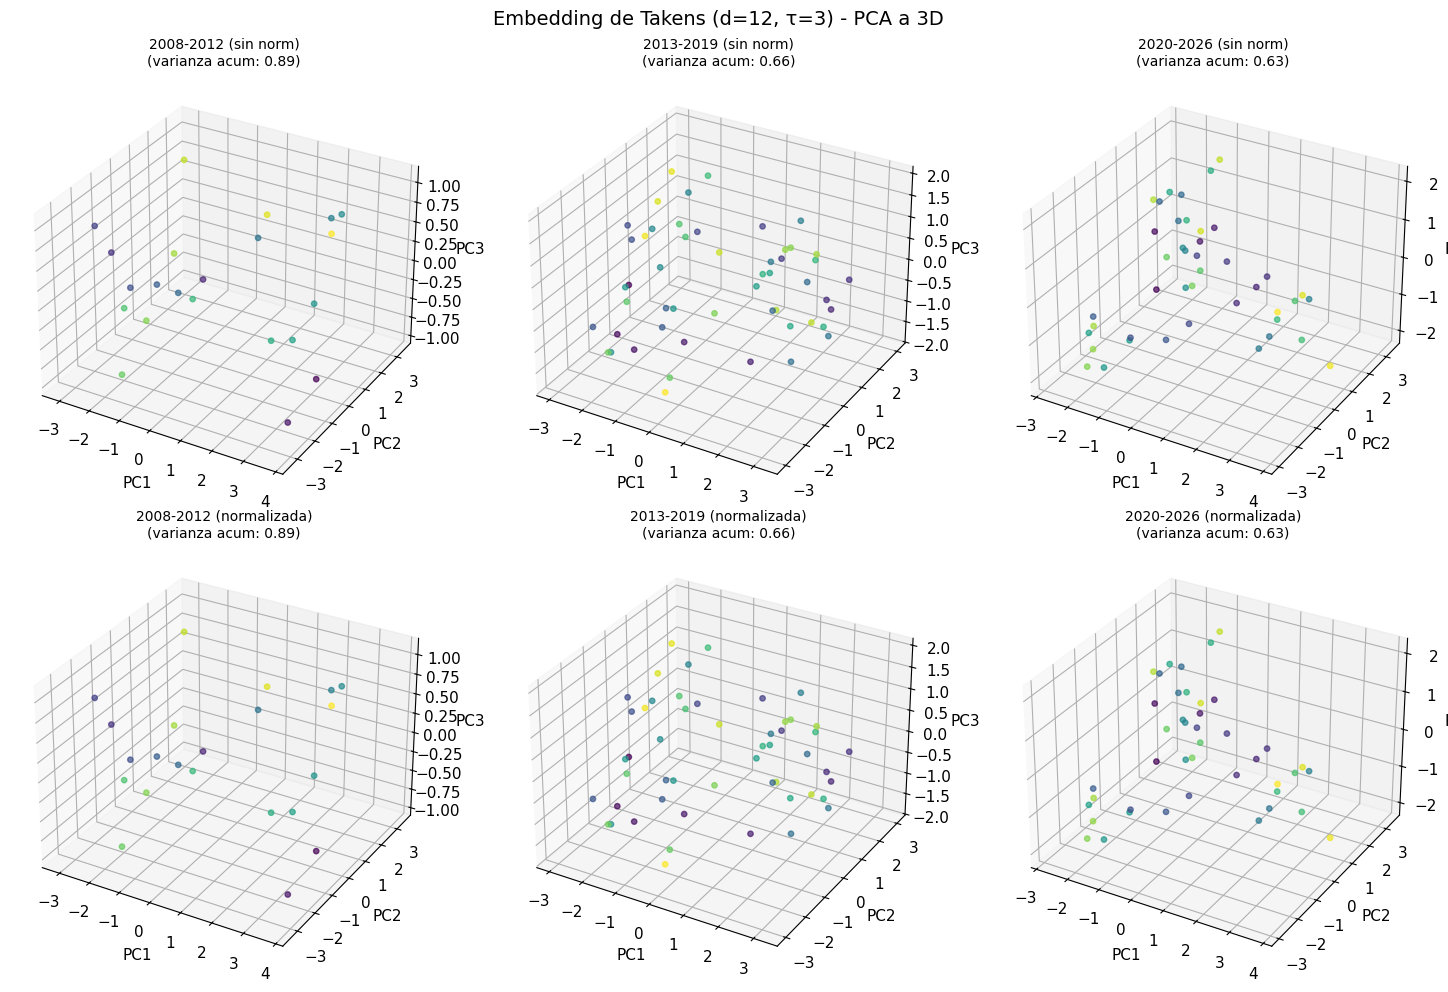

In [6]:
# ============================================================
# EMBEDDING DE TAKENS CON PARÁMETROS AJUSTABLES
# ============================================================

from gtda.time_series import SingleTakensEmbedding
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, IntSlider, FloatSlider

# Parámetros base
dimension = 12
time_delay = 3

print("="*60)
print("📊 CONFIGURACIÓN DEL EMBEDDING")
print("="*60)
print(f"   Dimensión (d): {dimension}")
print(f"   Retardo (τ): {time_delay}")
print(f"   Stride: 1")
print("="*60)

STE = SingleTakensEmbedding(
    parameters_type="fixed",
    dimension=dimension,
    time_delay=time_delay
)

# Calcular embeddings con normalización opcional
print("\n⏳ Calculando embeddings...")

# Opción 1: Sin normalizar
embedding_2008_raw = STE.fit_transform(precios_2008_2012)
embedding_2013_raw = STE.fit_transform(precios_2013_2019)
embedding_2020_raw = STE.fit_transform(precios_2020_2026)

# Opción 2: Normalizar los datos ANTES del embedding
scaler = StandardScaler()
precios_2008_norm = scaler.fit_transform(precios_2008_2012.reshape(-1, 1)).flatten()
precios_2013_norm = scaler.fit_transform(precios_2013_2019.reshape(-1, 1)).flatten()
precios_2020_norm = scaler.fit_transform(precios_2020_2026.reshape(-1, 1)).flatten()

embedding_2008_norm = STE.fit_transform(precios_2008_norm)
embedding_2013_norm = STE.fit_transform(precios_2013_norm)
embedding_2020_norm = STE.fit_transform(precios_2020_norm)

print(f"Embedding 2008-2012: {embedding_2008_raw.shape}")
print(f"Embedding 2013-2019: {embedding_2013_raw.shape}")
print(f"Embedding 2020-2026: {embedding_2020_raw.shape}")

# ============================================================
# PCA CON DIFERENTES CONFIGURACIONES
# ============================================================

from sklearn.decomposition import PCA

def plot_embedding_pca(embedding, title, ax, normalize=True, n_components=3, marker_size=15):
    """Función auxiliar para graficar PCA de embeddings"""
    
    # Normalización opcional
    if normalize:
        scaler_pca = StandardScaler()
        embedding_scaled = scaler_pca.fit_transform(embedding)
    else:
        embedding_scaled = embedding
    
    # PCA
    pca = PCA(n_components=n_components)
    embedding_pca = pca.fit_transform(embedding_scaled)
    
    # Varianza explicada
    var_exp = pca.explained_variance_ratio_
    print(f"   {title}: varianza PC1={var_exp[0]:.2f}, PC2={var_exp[1]:.2f}, PC3={var_exp[2]:.2f}")
    
    # Color por tiempo
    colors = np.linspace(0, 1, len(embedding_pca))
    
    # Graficar en 3D
    if n_components >= 3:
        ax.scatter(embedding_pca[:, 0], embedding_pca[:, 1], embedding_pca[:, 2],
                   c=colors, cmap='viridis', s=marker_size, alpha=0.7)
        ax.set_zlabel('PC3')
    else:
        ax.scatter(embedding_pca[:, 0], embedding_pca[:, 1],
                   c=colors, cmap='viridis', s=marker_size, alpha=0.7)
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{title}\n(varianza acum: {var_exp[0]+var_exp[1]+var_exp[2]:.2f})', fontsize=10)

# Crear figura comparativa
fig = plt.figure(figsize=(15, 10))

# Fila 1: Embeddings SIN normalización previa
ax1 = fig.add_subplot(231, projection='3d')
plot_embedding_pca(embedding_2008_raw, '2008-2012 (sin norm)', ax1, normalize=True)

ax2 = fig.add_subplot(232, projection='3d')
plot_embedding_pca(embedding_2013_raw, '2013-2019 (sin norm)', ax2, normalize=True)

ax3 = fig.add_subplot(233, projection='3d')
plot_embedding_pca(embedding_2020_raw, '2020-2026 (sin norm)', ax3, normalize=True)

# Fila 2: Embeddings CON normalización previa
ax4 = fig.add_subplot(234, projection='3d')
plot_embedding_pca(embedding_2008_norm, '2008-2012 (normalizada)', ax4, normalize=True)

ax5 = fig.add_subplot(235, projection='3d')
plot_embedding_pca(embedding_2013_norm, '2013-2019 (normalizada)', ax5, normalize=True)

ax6 = fig.add_subplot(236, projection='3d')
plot_embedding_pca(embedding_2020_norm, '2020-2026 (normalizada)', ax6, normalize=True)

plt.suptitle('Embedding de Takens (d=12, τ=3) - PCA a 3D', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# EXPLORACIÓN INTERACTIVA DE PARÁMETROS
# ============================================================

from ipywidgets import interact, IntSlider, FloatSlider
from sklearn.preprocessing import StandardScaler

def explore_embedding(dimension=12, time_delay=3, normalize=True):
    """Función interactiva para explorar diferentes parámetros"""
    
    STE = SingleTakensEmbedding(parameters_type="fixed", dimension=dimension, time_delay=time_delay)
    
    # Usar el subperiodo 2013-2019 c
    if normalize:
        scaler = StandardScaler()
        precios_norm = scaler.fit_transform(precios_2013_2019.reshape(-1, 1)).flatten()
        embedding = STE.fit_transform(precios_norm)
        title = f'2013-2019 (normalizada) | d={dimension}, τ={time_delay}'
    else:
        embedding = STE.fit_transform(precios_2013_2019)
        title = f'2013-2019 (sin normalizar) | d={dimension}, τ={time_delay}'
    
    # PCA
    pca = PCA(n_components=3)
    embedding_pca = pca.fit_transform(embedding)
    var_exp = pca.explained_variance_ratio_
    
    # Graficar
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = np.linspace(0, 1, len(embedding_pca))
    
    ax.scatter(embedding_pca[:, 0], embedding_pca[:, 1], embedding_pca[:, 2],
               c=colors, cmap='plasma', s=15, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'{title}\nVarianza explicada: {var_exp[0]+var_exp[1]+var_exp[2]:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Puntos en el embedding: {len(embedding)}")
    print(f"Dimensiones del embedding: {embedding.shape[1]}")

interact(explore_embedding,
         dimension=IntSlider(min=3, max=24, step=1, value=12),
         time_delay=IntSlider(min=1, max=12, step=1, value=3),
         normalize=True)

interactive(children=(IntSlider(value=12, description='dimension', max=24, min=3), IntSlider(value=3, descript…

<function __main__.explore_embedding(dimension=12, time_delay=3, normalize=True)>

## Actividad 3: Homología Persistente

Vamos a calcular diagramas de persistencia para cada subperiodo y analizar la presencia de ciclos (H₁).

**¿Qué buscamos?**
- **Persistencia alta** = estructura estacional real
- **Persistencia baja** = ruido o anomalías
- **Comparación entre periodos** para detectar cambios estructurales

In [8]:
# ============================================================
# CÁLCULO DE DIAGRAMAS DE PERSISTENCIA
# ============================================================

from gtda.homology import VietorisRipsPersistence

VR = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)

# Calcular diagramas para cada subperiodo
print("⏳ Calculando diagramas de persistencia...")
diagrams_2008 = VR.fit_transform([embedding_2008])[0]
diagrams_2013 = VR.fit_transform([embedding_2013])[0]
diagrams_2020 = VR.fit_transform([embedding_2020])[0]

print("✅ Diagramas calculados")

# Función para extraer persistencia máxima de H₁
def max_persistence_H1(diagrams):
    mask = diagrams[:, 2] == 1
    if np.any(mask):
        persistences = diagrams[mask, 1] - diagrams[mask, 0]
        return np.max(persistences), len(persistences)
    return 0, 0

max_pers_2008, n_cycles_2008 = max_persistence_H1(diagrams_2008)
max_pers_2013, n_cycles_2013 = max_persistence_H1(diagrams_2013)
max_pers_2020, n_cycles_2020 = max_persistence_H1(diagrams_2020)

print("\n" + "="*60)
print("📊 PERSISTENCIA MÁXIMA EN H₁ POR SUBPERIODO")
print("="*60)
print(f"2008-2012: {max_pers_2008:.4f} ({n_cycles_2008} ciclos detectados)")
print(f"2013-2019: {max_pers_2013:.4f} ({n_cycles_2013} ciclos detectados)")
print(f"2020-2026: {max_pers_2020:.4f} ({n_cycles_2020} ciclos detectados)")
print("="*60)

⏳ Calculando diagramas de persistencia...
✅ Diagramas calculados

📊 PERSISTENCIA MÁXIMA EN H₁ POR SUBPERIODO
2008-2012: 130.1262 (5 ciclos detectados)
2013-2019: 22.3533 (28 ciclos detectados)
2020-2026: 7.9953 (3 ciclos detectados)


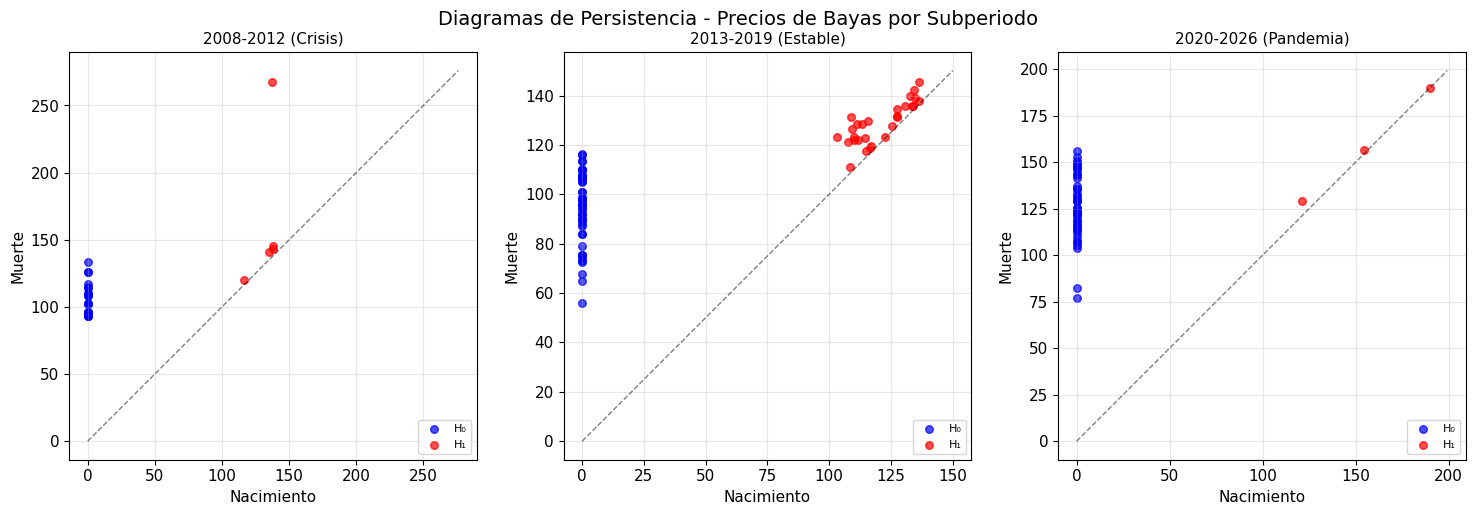

In [9]:
# ============================================================
# VISUALIZAR DIAGRAMAS 
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Lista de diagramas y títulos
diagramas_lista = [(diagrams_2008, '2008-2012 (Crisis)'),
                   (diagrams_2013, '2013-2019 (Estable)'),
                   (diagrams_2020, '2020-2026 (Pandemia)')]

for idx, (diagrams, titulo) in enumerate(diagramas_lista):
    ax = axes[idx]
    
    # Separar H₀ y H₁
    mask_H0 = diagrams[:, 2] == 0
    mask_H1 = diagrams[:, 2] == 1
    
    # Graficar H₀
    if np.any(mask_H0):
        ax.scatter(diagrams[mask_H0, 0], diagrams[mask_H0, 1], 
                   c='blue', s=30, alpha=0.7, label='H₀')
    
    # Graficar H₁
    if np.any(mask_H1):
        ax.scatter(diagrams[mask_H1, 0], diagrams[mask_H1, 1], 
                   c='red', s=30, alpha=0.7, label='H₁')
    
    # Diagonal
    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1]) if ax.get_xlim()[1] > 0 else 1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Nacimiento')
    ax.set_ylabel('Muerte')
    ax.set_title(titulo, fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Diagramas de Persistencia - Precios de Bayas por Subperiodo', fontsize=14)
plt.tight_layout()
plt.show()

## Preguntas de Análisis

1. **¿Qué diferencias observas en los embeddings 3D entre los tres subperiodos?**

2. **¿En qué subperiodo se detecta mayor persistencia en H₁? ¿Qué significa esto sobre la estacionalidad?**

3. **¿Hay algún subperiodo donde la topología se parece más a ruido? ¿Por qué crees que ocurre?**

4. **¿Cómo se relacionan los picos extremos (ej. 2024: 299.4) con la topología detectada?**

5. **¿Qué recomendación darías para modelar el precio de las berries usando estos hallazgos topológicos?**




